<a href="https://colab.research.google.com/github/alaaguedda/CNN_object_recognition/blob/main/Lab06_Advanced_CNN_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Lab 06 — Advanced CNN Models (Keras)
## Transfer Learning, Data Augmentation, Fine-Tuning, and Model Comparison

**Program:** First Year AI & Data Science  
**Duration:** 2 hours | **Semester:** S2

---

###  Lab Structure
| Part | Description |
|------|-------------|
| **E0** | Baseline CNN (trained from scratch) |
| **E1** | Transfer Learning — MobileNetV2 (frozen backbone) |
| **E2** | Fine-Tuning — MobileNetV2 (unfreeze last 20 layers) |
| **E3** | Backbone Comparison — ResNet50 (frozen) |
| **Q&A** | Concept + Code-based questions answered |

> ⚡ **Tip:** Go to `Runtime → Change runtime type → T4 GPU` for faster training.

## 0 Setup & Imports

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time
import matplotlib.pyplot as plt
import pandas as pd

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# ----------------------------
# Reproducibility
# ----------------------------
def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

TensorFlow version: 2.19.0
GPU available: True


## 1️⃣ Load & Prepare CIFAR-10 Dataset

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train: (50000, 32, 32, 3) (50000,)
Test:  (10000, 32, 32, 3) (10000,)


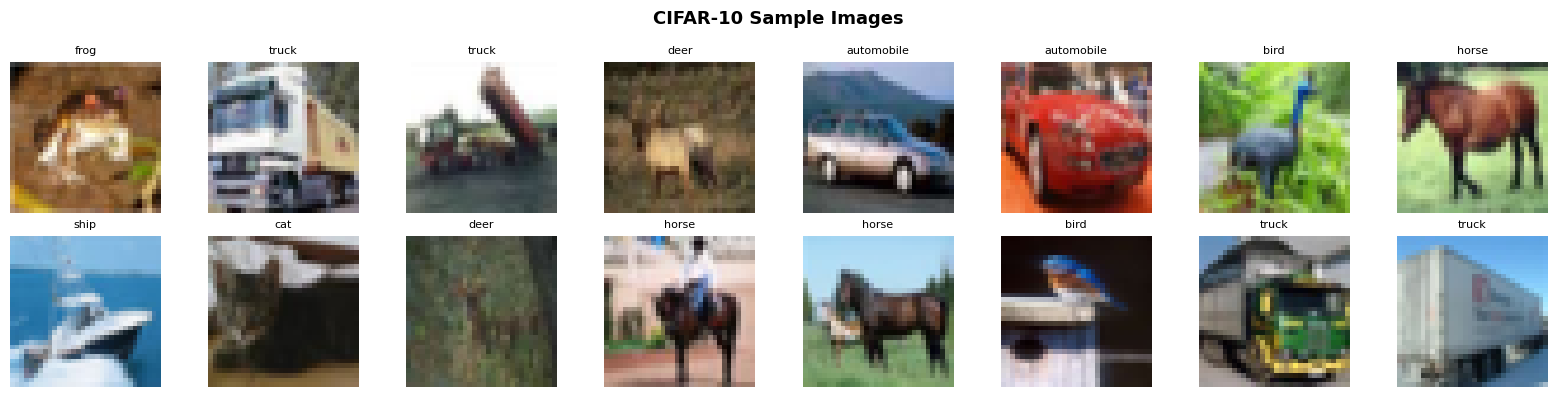

In [ ]:
# ----------------------------
# Load CIFAR-10
# ----------------------------
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train = y_train.squeeze().astype("int32")
y_test  = y_test.squeeze().astype("int32")

# Normalize to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# CIFAR-10 class names for reference
CLASS_NAMES = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

# ----------------------------
# Visualize a few samples
# ----------------------------
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=8)
    ax.axis("off")
plt.suptitle("CIFAR-10 Sample Images", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2️⃣ Shared Utilities: Resize, Augmentation & Training Helper

In [ ]:
# ----------------------------
# Resize helper (for pre-trained models)
# ----------------------------
IMG_SIZE = 96  # 96×96 — good balance of speed vs quality

def resize_images(x):
    return tf.image.resize(x, (IMG_SIZE, IMG_SIZE))

# ----------------------------
# Data Augmentation pipeline
# ----------------------------
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
], name="data_augmentation")

print("✅ Resize target:", IMG_SIZE, "×", IMG_SIZE)
print("✅ Augmentation layers: RandomFlip | RandomRotation | RandomZoom")

# ----------------------------
# Results tracker
# ----------------------------
results = {}  # { exp_name: {"acc": float, "time": float} }

# ----------------------------
# Training & evaluation helper
# ----------------------------
def train_and_eval(model, x_train, y_train, x_test, y_test,
                   epochs=10, batch_size=64, label="model"):
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=3, restore_best_weights=True
        )
    ]
    t0 = time.time()
    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=2
    )
    t1 = time.time()
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    elapsed = t1 - t0
    print(f"\n{'='*55}")
    print(f"  [{label}]  Test Loss={loss:.4f} | Test Acc={acc*100:.2f}% | Time={elapsed:.1f}s")
    print(f"{'='*55}\n")
    results[label] = {"Test Accuracy (%)": round(acc * 100, 2),
                      "Training Time (s)": round(elapsed, 1)}
    return history, (loss, acc)

# ----------------------------
# Plot training curves helper
# ----------------------------
def plot_history(history, title="Training Curves"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history["accuracy"],     label="Train Acc",  color="royalblue")
    axes[0].plot(history.history["val_accuracy"], label="Val Acc",    color="tomato", linestyle="--")
    axes[0].set_title(f"{title} — Accuracy"); axes[0].legend(); axes[0].set_xlabel("Epoch")
    axes[1].plot(history.history["loss"],         label="Train Loss", color="royalblue")
    axes[1].plot(history.history["val_loss"],     label="Val Loss",   color="tomato", linestyle="--")
    axes[1].set_title(f"{title} — Loss"); axes[1].legend(); axes[1].set_xlabel("Epoch")
    plt.tight_layout()
    plt.show()

✅ Resize target: 96 × 96
✅ Augmentation layers: RandomFlip | RandomRotation | RandomZoom


## 🔬 E0 — Baseline CNN (Trained from Scratch)

A simple Conv → Pool → Conv → Pool → Dense architecture with no pre-training.

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,746 (2.37 MB)

 Trainable params: 620,554 (2.37 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/10
625/625 - 13s - 20ms/step - accuracy: 0.4511 - loss: 1.5267 - val_accuracy: 0.5606 - val_loss: 1.2184
Epoch 2/10
625/625 - 4s - 6ms/step - accuracy: 0.5851 - loss: 1.1677 - val_accuracy: 0.5946 - val_loss: 1.1517
Epoch 3/10
625/625 - 3s - 5ms/step - accuracy: 0.6432 - loss: 1.0112 - val_accuracy: 0.6137 - val_loss: 1.1281
Epoch 4/10
625/625 - 3s - 5ms/step - accuracy: 0.6827 - loss: 0.9068 - val_accuracy: 0.7026 - val_loss: 0.8514
Epoch 5/10
625/625 - 3s - 5ms/step - accuracy: 0.7045 - loss: 0.8343 - val_accuracy: 0.7019 - val_loss: 0.8568
Epoch 6/10
625/625 - 4s - 6ms/step - accuracy: 0.7251 - loss: 0.7762 - val_accuracy: 0.7026 - val_loss: 0.8557
Epoch 7/10
625/625 - 3s - 5ms/step - accuracy: 0.7458 - loss: 0.7188 - val_accuracy: 0.6930 - val_loss: 0.9228

  [E0 — Baseline CNN]  Test Loss=0.8570 | Test Acc=70.08% | Time=35.6s



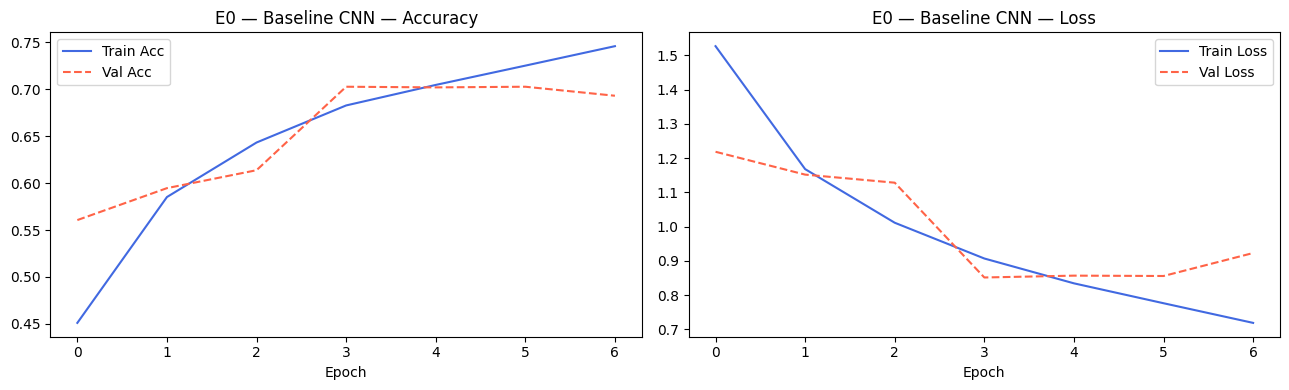

In [ ]:
# ----------------------------
# Build Baseline CNN
# ----------------------------
def build_baseline_cnn(input_shape=(32, 32, 3), lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dropout(0.4),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax"),
    ], name="Baseline_CNN")
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    return model

set_seed(42)
baseline = build_baseline_cnn()
baseline.summary()

hist_e0, _ = train_and_eval(
    baseline, x_train, y_train, x_test, y_test,
    epochs=10, batch_size=64, label="E0 — Baseline CNN"
)
plot_history(hist_e0, "E0 — Baseline CNN")

## 🔬 E1 — Transfer Learning: MobileNetV2 (Frozen Backbone)

The backbone is **frozen** — we only train the new classifier head on top of pre-learned ImageNet features.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 layers — Total: 154 | Trainable: 0 | Frozen: 154


Model: "MobileNetV2_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resize (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ backbone_preprocess (Lambda)    │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
625/625 - 26s - 42ms/step - accuracy: 0.1016 - loss: 2.3957 - val_accuracy: 0.0977 - val_loss: 2.3221
Epoch 2/10
625/625 - 17s - 27ms/step - accuracy: 0.1078 - loss: 2.3405 - val_accuracy: 0.0977 - val_loss: 2.3122
Epoch 3/10
625/625 - 18s - 29ms/step - accuracy: 0.1107 - loss: 2.3265 - val_accuracy: 0.0977 - val_loss: 2.3103
Epoch 4/10
625/625 - 20s - 32ms/step - accuracy: 0.1145 - loss: 2.3176 - val_accuracy: 0.0984 - val_loss: 2.3004
Epoch 5/10
625/625 - 17s - 28ms/step - accuracy: 0.1182 - loss: 2.3134 - val_accuracy: 0.0997 - val_loss: 2.2967
Epoch 6/10
625/625 - 17s - 28ms/step - accuracy: 0.1193 - loss: 2.3098 - val_accuracy: 0.1084 - val_loss: 2.2942
Epoch 7/10
625/625 - 17s - 27ms/step - accuracy: 0.1239 - loss: 2.3058 - val_accuracy: 0.1071 - val_loss: 2.2898
Epoch 8/10
625/625 - 17s - 27ms/step - accuracy: 0.1264 - loss: 2.3004 - val_accuracy: 0.1146 - val_loss: 2.2826
Epoch 9/10
625/625 - 17s - 27ms/step - accuracy: 0.1295 - loss: 2.2981 - val_accuracy: 0.1205 - 

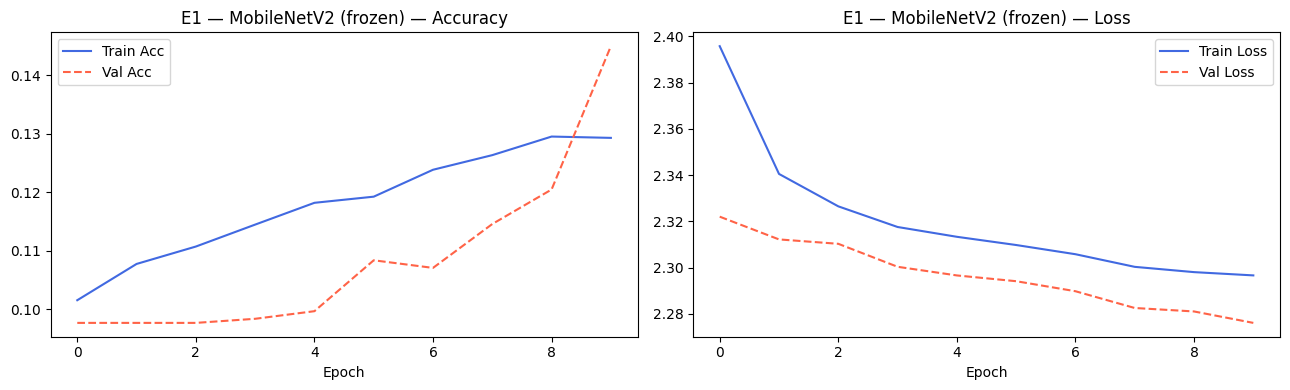

In [ ]:
# ----------------------------
# Build Transfer Learning / Fine-Tuning model
# ----------------------------
def build_transfer_model(backbone_name="MobileNetV2", lr=1e-3,
                         fine_tune=False, unfreeze_last=20):

    inputs = layers.Input(shape=(32, 32, 3))

    # 1. Augmentation (only active during training)
    x = data_augmentation(inputs)

    # 2. Resize to match backbone expected input
    x = layers.Lambda(resize_images, name="resize")(x)

    # 3. Choose backbone & its preprocessing function
    if backbone_name == "MobileNetV2":
        backbone = keras.applications.MobileNetV2(
            include_top=False, weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
        preprocess = keras.applications.mobilenet_v2.preprocess_input
    elif backbone_name == "ResNet50":
        backbone = keras.applications.ResNet50(
            include_top=False, weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
        preprocess = keras.applications.resnet.preprocess_input
    else:  # EfficientNetB0
        backbone = keras.applications.EfficientNetB0(
            include_top=False, weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
        preprocess = keras.applications.efficientnet.preprocess_input

    # 4. Preprocessing specific to backbone
    x = layers.Lambda(preprocess, name="backbone_preprocess")(x)

    # 5. Freeze backbone (feature extractor mode)
    backbone.trainable = False

    # 6. Run backbone in inference mode
    x = backbone(x, training=False)

    # 7. Classifier head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs, outputs,
                        name=f"{backbone_name}_{'finetune' if fine_tune else 'frozen'}")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    # 8. Optional fine-tuning: unfreeze last N layers
    if fine_tune:
        backbone.trainable = True
        for layer in backbone.layers[:-unfreeze_last]:
            layer.trainable = False
        # Recompile with a much smaller LR to avoid destroying pre-trained weights
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-5),
            loss=keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"]
        )

    return model, backbone


# ------ E1: Frozen MobileNetV2 ------
set_seed(42)
tl_model, bb = build_transfer_model("MobileNetV2", lr=1e-3, fine_tune=False)

# Show how many layers are trainable vs frozen
total   = len(bb.layers)
trainable = sum(1 for l in bb.layers if l.trainable)
print(f"MobileNetV2 layers — Total: {total} | Trainable: {trainable} | Frozen: {total-trainable}")
tl_model.summary()

hist_e1, _ = train_and_eval(
    tl_model, x_train, y_train, x_test, y_test,
    epochs=10, batch_size=64, label="E1 — MobileNetV2 (frozen)"
)
plot_history(hist_e1, "E1 — MobileNetV2 (frozen)")

## 🔬 E2 — Fine-Tuning: MobileNetV2 (Unfreeze Last 20 Layers)

We **unfreeze** the last 20 layers of the backbone and retrain with a very small learning rate (`1e-5`) so we gently adapt — not destroy — the pre-trained features.

MobileNetV2 (fine-tune) layers — Total: 154 | Trainable: 20 | Frozen: 134


Model: "MobileNetV2_finetune"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resize (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ backbone_preprocess (Lambda)    │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 1,218,890 (4.65 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

Epoch 1/10
625/625 - 34s - 54ms/step - accuracy: 0.2630 - loss: 2.0512 - val_accuracy: 0.1025 - val_loss: 2.6633
Epoch 2/10
625/625 - 24s - 39ms/step - accuracy: 0.3381 - loss: 1.8535 - val_accuracy: 0.1016 - val_loss: 3.0767
Epoch 3/10
625/625 - 24s - 38ms/step - accuracy: 0.3642 - loss: 1.7790 - val_accuracy: 0.0972 - val_loss: 4.2755
Epoch 4/10
625/625 - 24s - 38ms/step - accuracy: 0.3818 - loss: 1.7390 - val_accuracy: 0.1034 - val_loss: 4.6775

  [E2 — MobileNetV2 (fine-tuned)]  Test Loss=2.6695 | Test Acc=10.00% | Time=107.0s



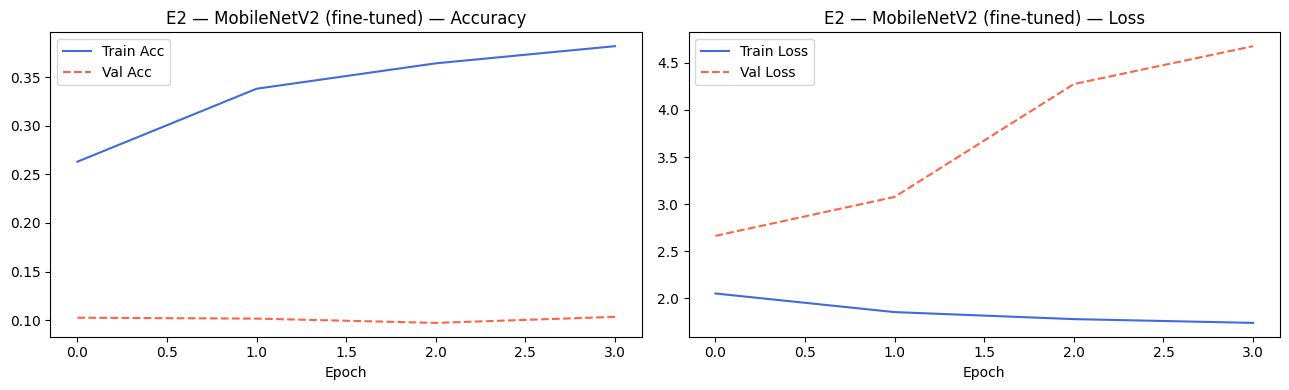

In [ ]:
set_seed(42)
ft_model, bb_ft = build_transfer_model(
    "MobileNetV2", lr=1e-3, fine_tune=True, unfreeze_last=20
)

total     = len(bb_ft.layers)
trainable = sum(1 for l in bb_ft.layers if l.trainable)
print(f"MobileNetV2 (fine-tune) layers — Total: {total} | Trainable: {trainable} | Frozen: {total-trainable}")
ft_model.summary()

hist_e2, _ = train_and_eval(
    ft_model, x_train, y_train, x_test, y_test,
    epochs=10, batch_size=64, label="E2 — MobileNetV2 (fine-tuned)"
)
plot_history(hist_e2, "E2 — MobileNetV2 (fine-tuned)")

## 🔬 E3 — Backbone Comparison: ResNet50 (Frozen)

We replace MobileNetV2 with **ResNet50** (same frozen-backbone setup) and compare.

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 layers — Total: 175 | Trainable: 0 | Frozen: 175


Model: "ResNet50_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resize (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ backbone_preprocess (Lambda)    │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
625/625 - 54s - 87ms/step - accuracy: 0.1421 - loss: 2.2791 - val_accuracy: 0.2432 - val_loss: 2.1918
Epoch 2/10
625/625 - 43s - 69ms/step - accuracy: 0.1901 - loss: 2.2004 - val_accuracy: 0.2651 - val_loss: 2.1267
Epoch 3/10
625/625 - 44s - 70ms/step - accuracy: 0.2068 - loss: 2.1615 - val_accuracy: 0.2770 - val_loss: 2.0862
Epoch 4/10
625/625 - 44s - 70ms/step - accuracy: 0.2194 - loss: 2.1340 - val_accuracy: 0.2859 - val_loss: 2.0560
Epoch 5/10
625/625 - 43s - 69ms/step - accuracy: 0.2223 - loss: 2.1166 - val_accuracy: 0.2979 - val_loss: 2.0318
Epoch 6/10
625/625 - 43s - 69ms/step - accuracy: 0.2304 - loss: 2.1033 - val_accuracy: 0.2999 - val_loss: 2.0129
Epoch 7/10
625/625 - 43s - 69ms/step - accuracy: 0.2353 - loss: 2.0910 - val_accuracy: 0.3029 - val_loss: 1.9994
Epoch 8/10
625/625 - 43s - 69ms/step - accuracy: 0.2361 - loss: 2.0806 - val_accuracy: 0.3061 - val_loss: 1.9871
Epoch 9/10
625/625 - 43s - 69ms/step - accuracy: 0.2438 - loss: 2.0719 - val_accuracy: 0.3116 - 

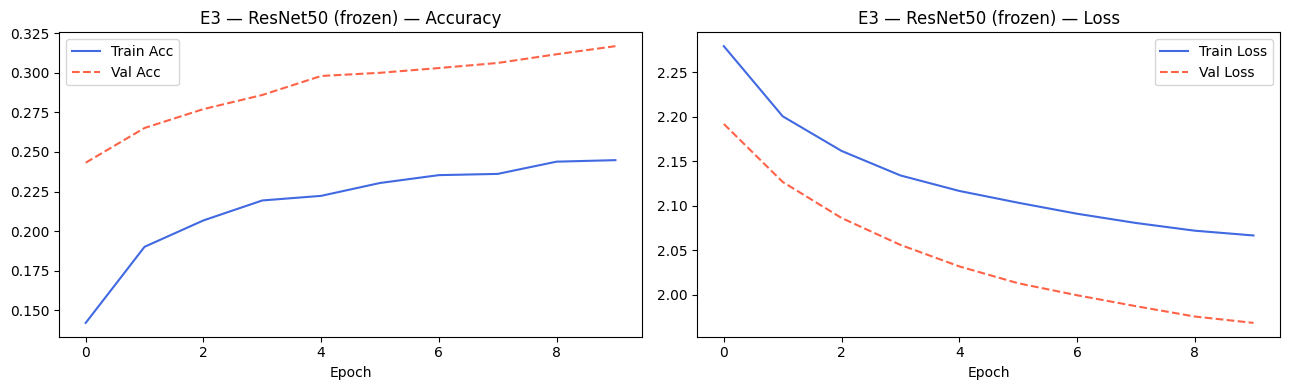

In [ ]:
set_seed(42)
cmp_model, bb_res = build_transfer_model("ResNet50", lr=1e-3, fine_tune=False)

total     = len(bb_res.layers)
trainable = sum(1 for l in bb_res.layers if l.trainable)
print(f"ResNet50 layers — Total: {total} | Trainable: {trainable} | Frozen: {total-trainable}")
cmp_model.summary()

hist_e3, _ = train_and_eval(
    cmp_model, x_train, y_train, x_test, y_test,
    epochs=10, batch_size=64, label="E3 — ResNet50 (frozen)"
)
plot_history(hist_e3, "E3 — ResNet50 (frozen)")

## 📊 Results Summary Table


           FINAL RESULTS TABLE
                   Experiment  Test Accuracy (%)  Training Time (s)
            E0 — Baseline CNN              70.08               35.6
       E3 — ResNet50 (frozen)              31.01              445.8
    E1 — MobileNetV2 (frozen)              14.98              184.7
E2 — MobileNetV2 (fine-tuned)              10.00              107.0


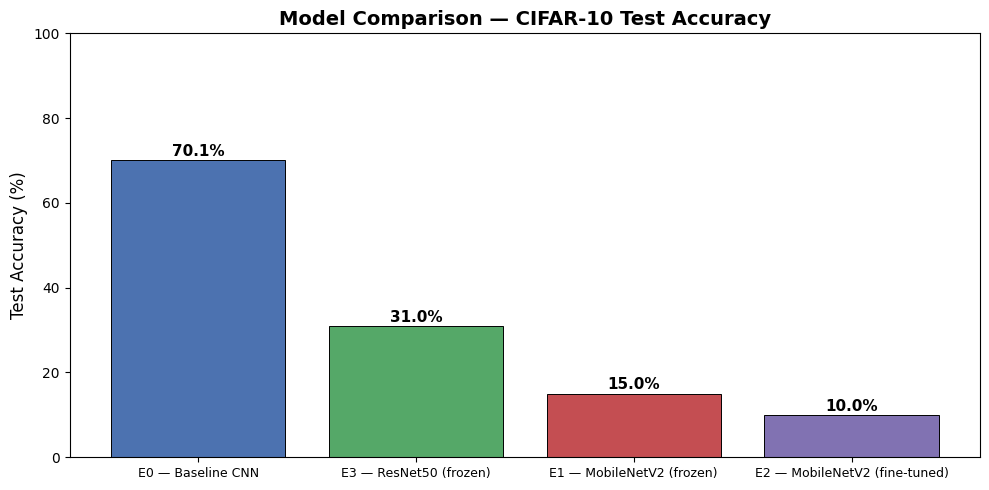

In [ ]:
df = pd.DataFrame(results).T.reset_index()
df.columns = ["Experiment", "Test Accuracy (%)", "Training Time (s)"]
df = df.sort_values("Test Accuracy (%)", ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("           FINAL RESULTS TABLE")
print("="*60)
print(df.to_string(index=False))
print("="*60)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
bars = ax.bar(df["Experiment"], df["Test Accuracy (%)"],
              color=colors[:len(df)], edgecolor="black", linewidth=0.7)
for bar, val in zip(bars, df["Test Accuracy (%)"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_ylim(0, 100)
ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_title("Model Comparison — CIFAR-10 Test Accuracy", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()
plt.show()

---
# 📝 Lab Questions — Answers

---

## Section 7.1 — Concept Questions

---

### Q1: What is transfer learning? Why is it useful?

**Transfer learning** is the technique of reusing a neural network that was pre-trained on a large dataset (e.g., ImageNet with 1.2 M images) as a starting point for a new, related task.

Instead of training all weights randomly from scratch, we:
1. Take the pre-trained model (the **backbone** or **feature extractor**).
2. Remove its final classification head.
3. Attach a new head suited to our task (e.g., 10-class softmax for CIFAR-10).
4. Train only the new head (or later fine-tune the backbone).

**Why it is useful:**
- **Less data needed** — the backbone already learned general visual features (edges, textures, shapes) from millions of images.
- **Faster training** — we only update a small number of parameters initially.
- **Higher accuracy** — pre-trained features transfer well even to new domains.
- **Reduces overfitting** — fewer parameters are optimised on the small dataset.

---

### Q2: What does `include_top=False` mean?

When loading a pre-trained model such as MobileNetV2, the `include_top=False` argument **removes the original classification head** (the final `GlobalAveragePooling2D + Dense(1000, softmax)` layers designed to classify 1000 ImageNet classes).

What remains is the **convolutional feature extractor** — all the learned convolutional and pooling layers — which outputs a feature map (a 3-D tensor) instead of class probabilities.

We then attach **our own custom head** on top of this feature map to classify our specific dataset (CIFAR-10's 10 classes in this lab).

---

### Q3: Why do we freeze the backbone in feature extraction?

Freezing means setting `backbone.trainable = False`, which prevents the backbone's weights from being updated during gradient descent.

**Reasons to freeze:**
1. **Preserve pre-trained knowledge** — the backbone already encodes powerful visual features; updating them with a small dataset (and large learning rate) would destroy this knowledge (a phenomenon called **catastrophic forgetting**).
2. **Faster training** — computing gradients for millions of frozen parameters is skipped; only the small classifier head is updated.
3. **Prevent overfitting** — fewer trainable parameters reduces the risk of overfitting on a small dataset.
4. **Stable early training** — the classifier head first learns to use the backbone's features before any fine-tuning begins.

---

### Q4: What is fine-tuning and why do we use a smaller learning rate?

**Fine-tuning** is the second phase of transfer learning where, after training the classifier head, we **unfreeze** some or all of the backbone layers and continue training the entire model end-to-end.

This allows the backbone to **specialise** its features for the target domain (CIFAR-10) rather than staying purely ImageNet-generic.

**Why a smaller learning rate (e.g., `1e-5` instead of `1e-3`)?**
- The pre-trained weights are already close to a good solution.
- A large learning rate would take big gradient steps that **overwrite (destroy) the learned representations** — a form of catastrophic forgetting.
- A very small learning rate makes **tiny, careful adjustments**, nudging the backbone features slightly toward the new task without erasing what was learned on ImageNet.
- Think of it as the difference between sculpting (fine-tuning, small moves) vs smashing (large LR, destructive).

---

### Q5: Explain data augmentation and give 3 examples.

**Data augmentation** is the practice of applying random — but realistic — transformations to training images at runtime, effectively expanding the dataset and teaching the model to be invariant to those transformations.

It reduces overfitting because the model rarely sees the exact same pixel values twice.

**3 examples used in this lab:**

| Augmentation | Keras Layer | Effect |
|---|---|---|
| **Horizontal Flip** | `RandomFlip("horizontal")` | Mirror the image left↔right; a cat is still a cat whether facing left or right |
| **Random Rotation** | `RandomRotation(0.08)` | Rotate up to ≈29°; makes the model robust to slightly tilted objects |
| **Random Zoom** | `RandomZoom(0.1)` | Randomly zoom in/out by 10%; simulates objects appearing at different distances |

Other common augmentations not used here: brightness/contrast jitter, cutout, colour jitter, shear, translation.

---

### Q6: What is EarlyStopping? How does it reduce overfitting?

**EarlyStopping** is a Keras callback that monitors a metric (here `val_loss`) and **stops training automatically** when that metric stops improving for a given number of epochs (`patience`).

```python
keras.callbacks.EarlyStopping(
    monitor='val_loss',   # metric to watch
    patience=3,           # stop if no improvement for 3 consecutive epochs
    restore_best_weights=True  # revert to the epoch with the best val_loss
)
```

**How it reduces overfitting:**
- Overfitting manifests as training loss decreasing while validation loss *increases*.
- EarlyStopping detects this divergence and halts training before the model memorises the training set.
- `restore_best_weights=True` ensures we keep the weights from the epoch where validation performance was best — not the last (possibly overfit) epoch.
- It also saves compute time by not running unnecessary epochs.

---

## Section 8.1 — Code-Based Questions

---

### Q7: Why do we resize CIFAR-10 images before using pre-trained backbones?

CIFAR-10 images are only **32×32 pixels**, whereas models like MobileNetV2 and ResNet50 were designed and trained on **224×224 images** (or at minimum ≥96×96 for MobileNetV2).

If we fed 32×32 images directly:
- The spatial feature maps would be **too small** after the first few strided convolutions/pooling layers, potentially collapsing to 1×1 or causing shape errors.
- The learned convolutional filters (designed to detect features at a certain spatial scale) would not activate meaningfully on such tiny inputs.

We resize to **96×96** (a compromise between quality and compute speed) so the backbone can produce meaningful intermediate feature maps.

---

### Q8: What is the purpose of the `preprocess_input` function?

Each backbone was trained with a specific **input normalisation** applied to its training data. The `preprocess_input` function replicates that exact preprocessing so that the backbone receives inputs in the same scale/format it was trained on.

| Backbone | `preprocess_input` does |
|---|---|
| **MobileNetV2** | Scales pixels from `[0, 255]` → `[-1, 1]` |
| **ResNet50** | Subtracts ImageNet channel means (BGR order), no rescaling to [-1,1] |
| **EfficientNetB0** | Scales pixels from `[0, 255]` → `[0, 1]` (built internally) |

Skipping this step means the backbone receives inputs in the wrong range, causing incorrect feature activations and significantly lower accuracy.

---

### Q9: What is the difference between `GlobalAveragePooling2D` and `Flatten`?

Both convert a 3-D feature map `(H, W, C)` to a 1-D vector, but differently:

| | `Flatten` | `GlobalAveragePooling2D` |
|---|---|---|
| **Operation** | Concatenates all spatial pixels: `H × W × C` values | Averages each channel spatially: outputs `C` values |
| **Output size** | `H × W × C` (very large) | `C` (compact) |
| **Example** | 3×3×512 → 4608 values | 3×3×512 → 512 values |
| **Parameters** | Large Dense layer needed | Small Dense layer needed |
| **Overfitting risk** | Higher (many weights) | Lower |
| **Spatial invariance** | None — position matters | High — position averaged out |
| **Use case** | Small custom CNNs | Transfer learning with large backbones |

In transfer learning, `GlobalAveragePooling2D` is preferred because it produces a compact, spatially invariant feature vector and drastically reduces the number of parameters in the classifier head.

---

### Q10: Where is data augmentation applied in the model graph? Why is that better than offline augmentation?

In our code, data augmentation is the **first layer inside the model graph**, applied to the raw input tensor before preprocessing and backbone inference:

```
Input → [data_augmentation] → resize → preprocess → backbone → GAP → Dropout → Dense
```

This is called **online (on-the-fly) augmentation** — a new random transformation is applied every time a batch is processed during training.

**Advantages over offline augmentation (pre-generating augmented images on disk):**

| Aspect | Online (in-graph) | Offline (on disk) |
|---|---|---|
| **Variety** | Infinite — new random transform each epoch | Fixed — same augmented images every epoch |
| **Storage** | No extra disk space | Dataset multiplied in size |
| **GPU usage** | Runs on GPU, no bottleneck | CPU preprocessing may cause bottlenecks |
| **Flexibility** | Change augmentation without regenerating data | Requires re-running augmentation pipeline |
| **Auto-disabled** | Keras disables augmentation at inference time (via `training=False`) | Must be careful not to augment test data |

---

### Q11: In fine-tuning, why do we unfreeze only the last layers instead of all layers?

The layers of a CNN learn features at different levels of abstraction:

- **Early layers** → low-level, generic features (edges, corners, colour gradients) — **universal across all images**.
- **Middle layers** → intermediate patterns (textures, object parts) — somewhat task-specific.
- **Last layers** → high-level, task-specific features (semantic representations) — **most domain-specific**.

Since CIFAR-10 is different from ImageNet, the **last layers need the most adaptation** (ImageNet has 1000 classes with fine-grained distinctions; CIFAR-10 has 10 coarser classes).

**Reasons to keep early layers frozen:**
1. Early features (edge detectors, etc.) are already optimal and universal — changing them would degrade performance.
2. Freezing most of the network prevents catastrophic forgetting and overfitting.
3. Fewer trainable parameters → faster training and lower memory usage.
4. The small learning rate applied to the unfrozen last layers is still risky for early layers — their weight scale is calibrated for ImageNet.

Unfreezing too many layers on a small dataset typically leads to **overfitting**.

---

### Q12: Compare the best result among E0–E3. Which model was best and why?
* basline model performes better


